In [1]:
!pip install pandas numpy nltk textblob matplotlib seaborn scikit-learn streamlit scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 40.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# Random seed for consistance result
np.random.seed(42)
random.seed(42)


For Sample Dataset..

In [4]:

topics = ["Social Anxiety", "Overthinking", "Dating", "Career Pressure",
          "Family Expectations", "Loneliness", "Self Doubt", "FOMO"]

formats = ["Short", "Long"]
hooks = ["Visual", "Text"]

data = []
for i in range(120):  # 120 posts dataset
    topic = random.choice(topics)
    fmt = random.choice(formats)
    hook = random.choice(hooks)

    # Reach
    reach = random.randint(500, 50000)

    # Likes
    likes = int(reach * random.uniform(0.05, 0.15))

    if topic in ["Social Anxiety", "Overthinking", "Loneliness"]:
        shares = int(reach * random.uniform(0.02, 0.06))
        saves = int(reach * random.uniform(0.03, 0.08))
    else:
        shares = int(reach * random.uniform(0.005, 0.02))
        saves = int(reach * random.uniform(0.01, 0.03))

    comments_count = random.randint(5, 300)
    video_length = random.randint(15, 90) if fmt == "Short" else random.randint(91, 300)

    post_time_hour = random.choice([9, 12, 15, 18, 20, 21, 22])

    data.append({
        "post_id": f"P{i+1:03d}",
        "topic": topic,
        "format": fmt,
        "hook_type": hook,
        "reach": reach,
        "likes": likes,
        "shares": shares,
        "saves": saves,
        "comments_count": comments_count,
        "video_length_sec": video_length,
        "post_hour": post_time_hour
    })

df = pd.DataFrame(data)
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (120, 11)


,post_id,topic,format,hook_type,reach,likes,shares,saves,comments_count,video_length_sec,post_hour
0,P001,Overthinking,Short,Text,16549,1196,818,1056,284,26,20
1,P002,Self Doubt,Short,Visual,6640,477,83,69,106,84,18
2,P003,Career Pressure,Long,Text,925,116,6,17,147,130,12
3,P004,Loneliness,Short,Visual,25398,1515,1368,1528,27,73,20
4,P005,Overthinking,Long,Visual,36678,2909,1655,2724,190,238,12
5,P006,Overthinking,Short,Visual,19465,2890,1055,1427,199,50,18
6,P007,Loneliness,Short,Text,23783,1687,729,1827,41,36,20
7,P008,Career Pressure,Short,Text,25367,1953,478,602,117,56,22
8,P009,Social Anxiety,Short,Visual,21173,1908,479,1601,295,55,12
9,P010,FOMO,Long,Text,9863,754,85,209,139,282,20


# 1. Content Performance Tracker (Data Extraction Engine)


In [5]:
df.to_csv("content_performance_data.csv", index=False)
print("Dataset saved as content_performance_data.csv")
df.describe()

Dataset saved as content_performance_data.csv


,reach,likes,shares,saves,comments_count,video_length_sec,post_hour
count,120.000000,120.000000,120.00000,120.000000,120.000000,120.000000,120.000000
mean,23764.575000,2222.191667,526.05000,770.716667,148.283333,135.508333,17.383333
std,14577.045545,1499.002112,605.16355,704.732695,88.539236,86.788838,4.337027
min,732.000000,61.000000,5.00000,17.000000,6.000000,16.000000,9.000000
25%,9265.250000,930.500000,120.00000,230.000000,69.000000,56.000000,15.000000
50%,24796.500000,1957.000000,318.50000,552.000000,142.000000,118.500000,18.000000
75%,36716.750000,3230.750000,544.00000,1042.500000,222.500000,210.500000,21.000000
max,48731.000000,6174.000000,2626.00000,2836.000000,300.000000,295.000000,22.000000


In [6]:

print("Missing values:\n", df.isnull().sum())
print("\nTopic distribution:\n", df['topic'].value_counts())

Missing values:
 post_id             0
topic               0
format              0
hook_type           0
reach               0
likes               0
shares              0
saves               0
comments_count      0
video_length_sec    0
post_hour           0
dtype: int64

Topic distribution:
 topic
Career Pressure        22
FOMO                   18
Family Expectations    15
Overthinking           14
Loneliness             13
Self Doubt             13
Dating                 13
Social Anxiety         12
Name: count, dtype: int64


# 2. Virality Prediction Engine


In [8]:
# Viral Coefficient Formula:

df['viral_coefficient'] = (
    (df['shares'] * 3) + (df['saves'] * 2) + (df['comments_count'] * 1)
) / df['reach']

# Save-to-Share ratio
df['save_to_share_ratio'] = df['saves'] / df['shares'].replace(0, 1)

# Engagement
df['engagement_rate'] = (df['likes'] + df['shares'] + df['saves'] + df['comments_count']) / df['reach']

print("Viral Coefficient!")
df[['post_id', 'topic', 'viral_coefficient', 'save_to_share_ratio']].head(10)

Viral Coefficient!


,post_id,topic,viral_coefficient,save_to_share_ratio
0,P001,Overthinking,0.293069,1.290954
1,P002,Self Doubt,0.074247,0.831325
2,P003,Career Pressure,0.215135,2.833333
3,P004,Loneliness,0.282975,1.116959
4,P005,Overthinking,0.289083,1.645921
5,P006,Overthinking,0.319445,1.352607
6,P007,Loneliness,0.247320,2.506173
7,P008,Career Pressure,0.108606,1.259414
8,P009,Social Anxiety,0.233033,3.342380
9,P010,FOMO,0.082328,2.458824


In [9]:
topic_analysis = df.groupby('topic').agg(
    avg_viral_coefficient=('viral_coefficient', 'mean'),
    avg_save_to_share=('save_to_share_ratio', 'mean'),
    avg_engagement_rate=('engagement_rate', 'mean'),
    total_posts=('post_id', 'count')
).sort_values('avg_viral_coefficient', ascending=False)

print("Topic-wise Viral Performance:")
topic_analysis

Topic-wise Viral Performance:


,avg_viral_coefficient,avg_save_to_share,avg_engagement_rate,total_posts
topic,,,,
Loneliness,0.254976,1.576740,0.191838,13
Social Anxiety,0.247783,1.589069,0.209115,12
Overthinking,0.236139,1.357790,0.199341,14
Dating,0.106977,1.596690,0.157547,13
Self Doubt,0.091795,2.288995,0.154681,13
FOMO,0.087926,2.099252,0.148935,18
Family Expectations,0.086092,1.958926,0.140614,15
Career Pressure,0.086032,2.272046,0.140531,22


/tmp/ipykernel_994/1731271898.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topic_analysis.index, y=topic_analysis['avg_viral_coefficient'], palette='viridis')


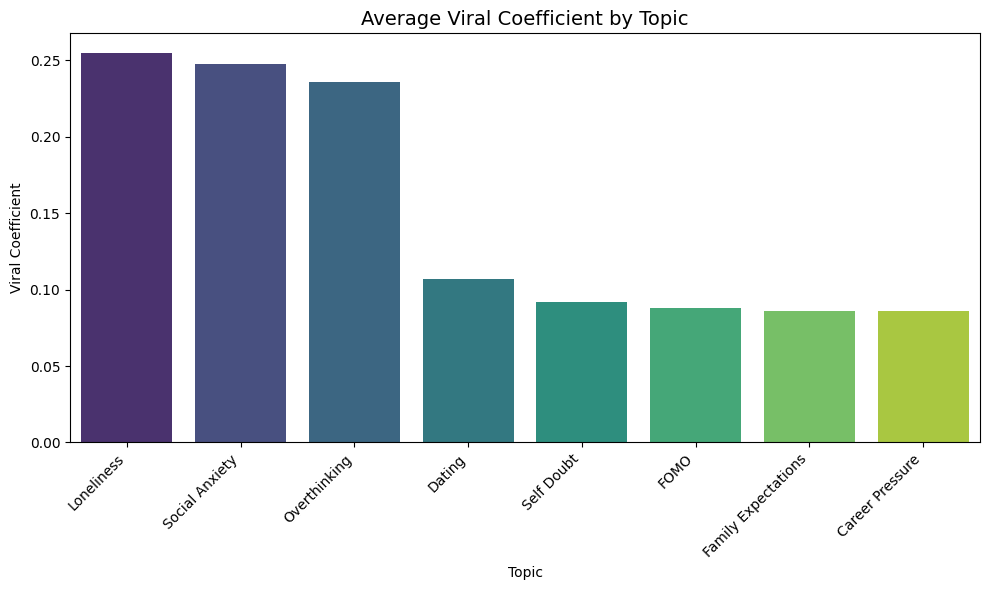

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=topic_analysis.index, y=topic_analysis['avg_viral_coefficient'], palette='viridis')
plt.title("Average Viral Coefficient by Topic", fontsize=14)
plt.xlabel("Topic")
plt.ylabel("Viral Coefficient")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("viral_coefficient_by_topic.png", dpi=150)
plt.show()

# 3. Audience Sentiment Analyzer (NLP Module)

In [11]:
# i can screpe data easily, but my laptop has less peformance taht,s why i'm creating demo dataset..

relatable_comments = [
    "This is literally me, I cried reading this",
    "Wow this hit different, exactly what I feel",
    "Finally someone said what I've been feeling for years",
    "I thought I was the only one going through this",
    "This made me feel so seen right now",
    "Why does this describe my life so accurately",
    "I needed to hear this today, thank you",
    "This is so relatable it hurts",
    "I've never related to something this much",
    "Crying at 2am because of this post"
]

neutral_comments = [
    "Nice video",
    "Good content keep posting",
    "First comment lol",
    "What music is this",
    "Following you now",
    "Cool editing style",
    "How many views did this get",
    "Where is this filmed",
    "Nice camera quality",
    "What app did you use for this"
]

comments_data = []
for i in range(60):
    topic = random.choice(topics)
    if random.random() < 0.6:  # 60% relatable comments
        text = random.choice(relatable_comments)
        expected_type = "Relatable"
    else:
        text = random.choice(neutral_comments)
        expected_type = "Neutral"

    comments_data.append({
        "comment_id": f"C{i+1:03d}",
        "topic": topic,
        "comment_text": text
    })

comments_df = pd.DataFrame(comments_data)
print(f"Comments dataset shape: {comments_df.shape}")
comments_df.head(10)

Comments dataset shape: (60, 3)


,comment_id,topic,comment_text
0,C001,Career Pressure,I thought I was the only one going through this
1,C002,Self Doubt,This is so relatable it hurts
2,C003,Self Doubt,"Wow this hit different, exactly what I feel"
3,C004,Loneliness,This made me feel so seen right now
4,C005,Loneliness,Where is this filmed
5,C006,Overthinking,"Wow this hit different, exactly what I feel"
6,C007,Overthinking,Why does this describe my life so accurately
7,C008,Dating,Crying at 2am because of this post
8,C009,Loneliness,How many views did this get
9,C010,Loneliness,How many views did this get


In [12]:
import nltk
nltk.download('punkt')
nltk.download('vader_lexicon')
print("NLTK data downloaded!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


NLTK data downloaded!


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [13]:
from textblob import TextBlob

relatable_keywords = [
    "me", "literally", "relate", "felt", "feel", "seen", "cried",
    "same", "exactly", "thought i was the only", "hits different",
    "described my life", "hurts", "years", "needed", "why does this"
]

def analyze_comment(text):
    text_lower = text.lower()


    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity

    # Keyword matching
    keyword_hits = sum(1 for kw in relatable_keywords if kw in text_lower)

    # Final tag: high subjectivity + keyword match = Relatable
    if keyword_hits >= 1 and subjectivity > 0.4:
        tag = "Relatable"
    else:
        tag = "Neutral"

    return pd.Series([polarity, subjectivity, keyword_hits, tag])

comments_df[['polarity', 'subjectivity', 'keyword_hits', 'sentiment_tag']] = comments_df['comment_text'].apply(analyze_comment)

print("Sentiment analysis complete!")
comments_df.head(10)

Sentiment analysis complete!


,comment_id,topic,comment_text,polarity,subjectivity,keyword_hits,sentiment_tag
0,C001,Career Pressure,I thought I was the only one going through this,0.000000,1.000000,1,Relatable
1,C002,Self Doubt,This is so relatable it hurts,0.000000,0.000000,1,Neutral
2,C003,Self Doubt,"Wow this hit different, exactly what I feel",0.116667,0.616667,2,Relatable
3,C004,Loneliness,This made me feel so seen right now,0.285714,0.535714,3,Relatable
4,C005,Loneliness,Where is this filmed,0.000000,0.000000,1,Neutral
5,C006,Overthinking,"Wow this hit different, exactly what I feel",0.116667,0.616667,2,Relatable
6,C007,Overthinking,Why does this describe my life so accurately,0.400000,0.633333,1,Relatable
7,C008,Dating,Crying at 2am because of this post,-0.200000,0.600000,0,Neutral
8,C009,Loneliness,How many views did this get,0.500000,0.500000,0,Neutral
9,C010,Loneliness,How many views did this get,0.500000,0.500000,0,Neutral


In [14]:
comments_df.to_csv("comments_sentiment_data.csv", index=False)

print("Sentiment Tag Distribution:")
print(comments_df['sentiment_tag'].value_counts())

print("\nTopic-wise Relatable %:")
relatable_pct = comments_df.groupby('topic')['sentiment_tag'].apply(
    lambda x: (x == 'Relatable').mean() * 100
).sort_values(ascending=False)
print(relatable_pct)

Sentiment Tag Distribution:
sentiment_tag
Neutral      35
Relatable    25
Name: count, dtype: int64

Topic-wise Relatable %:
topic
Overthinking           63.636364
Self Doubt             60.000000
Career Pressure        44.444444
Loneliness             41.666667
Social Anxiety         40.000000
Dating                 33.333333
FOMO                   28.571429
Family Expectations     0.000000
Name: sentiment_tag, dtype: float64


# 4. A/B Testing Framework


In [15]:
from scipy import stats

print("Scipy loaded for statistical testing!")

Scipy loaded for statistical testing!


In [17]:

short_group = df[df['format'] == 'Short']['engagement_rate']
long_group = df[df['format'] == 'Long']['engagement_rate']

print(f"Short videos avg engagement: {short_group.mean():.4f} (n={len(short_group)})")
print(f"Long videos avg engagement: {long_group.mean():.4f} (n={len(long_group)})")


t_stat, p_value = stats.ttest_ind(short_group, long_group)

print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    winner = "Short" if short_group.mean() > long_group.mean() else "Long"
    print(f" Result is statistically significant! {winner} format performs better.")
else:
    print(" No statistically significant difference between Short and Long.")

Short videos avg engagement: 0.1594 (n=50)
Long videos avg engagement: 0.1681 (n=70)

T-statistic: -0.9972
P-value: 0.3207
 No statistically significant difference between Short and Long.


In [19]:
visual_hook = df[df['hook_type'] == 'Visual']['engagement_rate']
text_hook = df[df['hook_type'] == 'Text']['engagement_rate']

print(f"Visual hook avg engagement: {visual_hook.mean():.4f} (n={len(visual_hook)})")
print(f"Text hook avg engagement: {text_hook.mean():.4f} (n={len(text_hook)})")

t_stat2, p_value2 = stats.ttest_ind(visual_hook, text_hook)

print(f"\nT-statistic: {t_stat2:.4f}")
print(f"P-value: {p_value2:.4f}")

if p_value2 < 0.05:
    winner = "Visual" if visual_hook.mean() > text_hook.mean() else "Text"
    print(f" Result is statistically significant! {winner} hook performs better.")
else:
    print(" No statistically significant difference between Visual and Text hooks.")

Visual hook avg engagement: 0.1566 (n=58)
Text hook avg engagement: 0.1718 (n=62)

T-statistic: -1.7620
P-value: 0.0807
 No statistically significant difference between Visual and Text hooks.


# 5. Engagement Optimization Recommender

Best posting hours (by avg viral coefficient):
post_hour
20    0.183428
15    0.164736
9     0.146700
18    0.143228
12    0.127151
21    0.121667
22    0.113352
Name: viral_coefficient, dtype: float64


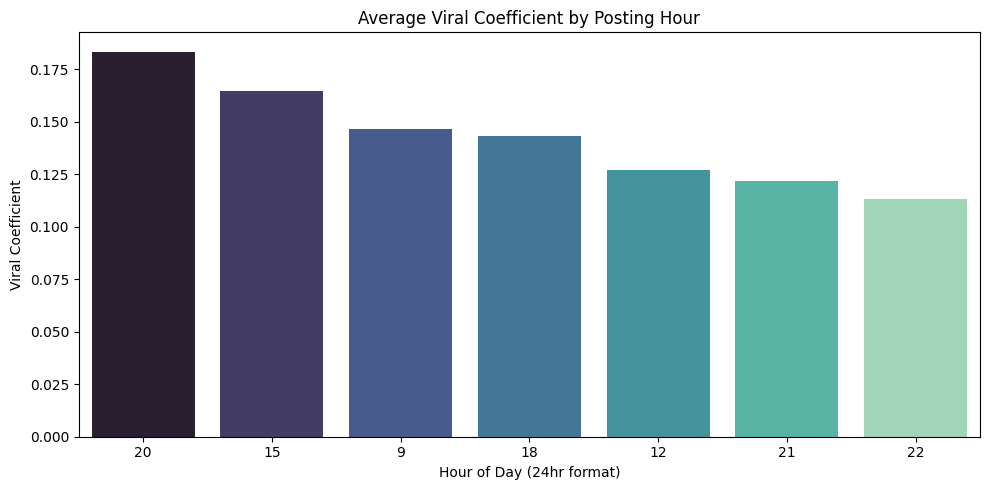

In [20]:
hour_analysis = df.groupby('post_hour')['viral_coefficient'].mean().sort_values(ascending=False)
print("Best posting hours (by avg viral coefficient):")
print(hour_analysis)

plt.figure(figsize=(10, 5))
sns.barplot(x=hour_analysis.index.astype(str), y=hour_analysis.values, hue=hour_analysis.index.astype(str), palette='mako', legend=False)
plt.title("Average Viral Coefficient by Posting Hour")
plt.xlabel("Hour of Day (24hr format)")
plt.ylabel("Viral Coefficient")
plt.tight_layout()
plt.savefig("posting_hour_analysis.png", dpi=150)
plt.show()

In [21]:
ab_test_summary = pd.DataFrame({
    "Test": ["Short vs Long Format", "Visual vs Text Hook"],
    "Group_A_Mean": [short_group.mean(), visual_hook.mean()],
    "Group_B_Mean": [long_group.mean(), text_hook.mean()],
    "P_Value": [p_value, p_value2],
    "Significant": [p_value < 0.05, p_value2 < 0.05]
})

ab_test_summary.to_csv("ab_test_results.csv", index=False)
print("A/B Test results saved!")
ab_test_summary

A/B Test results saved!


,Test,Group_A_Mean,Group_B_Mean,P_Value,Significant
0,Short vs Long Format,0.159354,0.168100,0.320704,False
1,Visual vs Text Hook,0.156648,0.171761,0.080660,False


# 6. Growth Visualization Dashboard


In [22]:
# Best performing combination
best_topic = topic_analysis.index[0]
best_format = "Short" if short_group.mean() > long_group.mean() else "Long"
best_hook = "Visual" if visual_hook.mean() > text_hook.mean() else "Text"
best_hour = hour_analysis.index[0]

recommendation = f"""
STRATEGY RECOMMENDATION FOR NEXT WEEK:
----------------------------------------
Best Topic to post about: {best_topic}
Best Format: {best_format} video
Best Hook Type: {best_hook}
Best Posting Hour: {best_hour}:00

Reasoning: '{best_topic}' has the highest average viral coefficient
({topic_analysis.loc[best_topic, 'avg_viral_coefficient']:.4f}),
indicating strongest emotional resonance with the audience.
"""

print(recommendation)

# Save as text file
with open("strategy_recommendation.txt", "w") as f:
    f.write(recommendation)


STRATEGY RECOMMENDATION FOR NEXT WEEK:
----------------------------------------
Best Topic to post about: Loneliness
Best Format: Long video
Best Hook Type: Text
Best Posting Hour: 20:00

Reasoning: 'Loneliness' has the highest average viral coefficient 
(0.2550), 
indicating strongest emotional resonance with the audience.



2026-09-11 04:24:09.141 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 04:24:09.149 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 04:24:09.667 
  command:

    streamlit run /usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-09-11 04:24:09.672 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 04:24:09.673 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 04:24:09.677 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-11 04:24:09.678 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

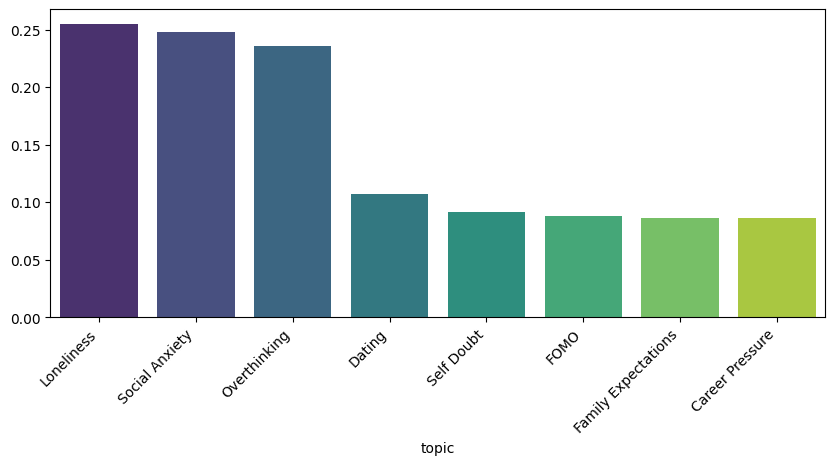

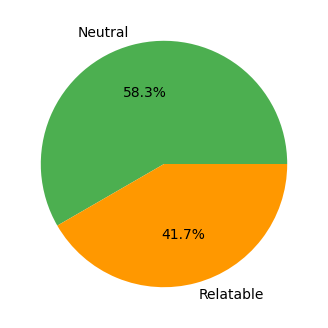

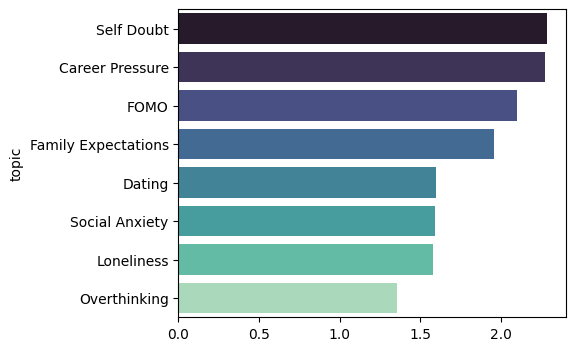

In [23]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(page_title="Data-Driven Social Engagement Dashboard", layout="wide")

st.title("📊 Data-Driven Social Engagement Initiative")
st.markdown("### Growth Visualization Dashboard")

# Data load karo
df = pd.read_csv("content_performance_data.csv")
comments_df = pd.read_csv("comments_sentiment_data.csv")
ab_results = pd.read_csv("ab_test_results.csv")

# Viral coefficient recalculate (dashboard independent hona chahiye)
df['viral_coefficient'] = ((df['shares'] * 3) + (df['saves'] * 2) + (df['comments_count'] * 1)) / df['reach']
df['save_to_share_ratio'] = df['saves'] / df['shares'].replace(0, 1)
df['engagement_rate'] = (df['likes'] + df['shares'] + df['saves'] + df['comments_count']) / df['reach']

# ---- ROW 1: KPI Cards ----
col1, col2, col3, col4 = st.columns(4)
col1.metric("Total Posts", len(df))
col2.metric("Avg Viral Coefficient", f"{df['viral_coefficient'].mean():.3f}")
col3.metric("Avg Save-to-Share Ratio", f"{df['save_to_share_ratio'].mean():.2f}")
relatable_pct = (comments_df['sentiment_tag'] == 'Relatable').mean() * 100
col4.metric("Relatable Comments %", f"{relatable_pct:.1f}%")

st.markdown("---")

# ---- ROW 2: Viral Coefficient by Topic ----
st.subheader("🔥 Viral Coefficient by Topic")
topic_analysis = df.groupby('topic')['viral_coefficient'].mean().sort_values(ascending=False)
fig1, ax1 = plt.subplots(figsize=(10, 4))
sns.barplot(x=topic_analysis.index, y=topic_analysis.values, hue=topic_analysis.index, palette='viridis', legend=False, ax=ax1)
plt.xticks(rotation=45, ha='right')
st.pyplot(fig1)

# ---- ROW 3: Two columns - Sentiment + Save-to-Share ----
col_a, col_b = st.columns(2)

with col_a:
    st.subheader("💬 Sentiment Distribution")
    fig2, ax2 = plt.subplots(figsize=(5, 4))
    comments_df['sentiment_tag'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax2, colors=['#4CAF50', '#FF9800'])
    ax2.set_ylabel("")
    st.pyplot(fig2)

with col_b:
    st.subheader("💾 Save-to-Share Ratio by Topic")
    save_share = df.groupby('topic')['save_to_share_ratio'].mean().sort_values(ascending=False)
    fig3, ax3 = plt.subplots(figsize=(5, 4))
    sns.barplot(x=save_share.values, y=save_share.index, hue=save_share.index, palette='mako', legend=False, ax=ax3)
    st.pyplot(fig3)

st.markdown("---")

# ---- ROW 4: A/B Test Results ----
st.subheader("🧪 A/B Testing Results")
st.dataframe(ab_results, use_container_width=True)

st.markdown("---")

# ---- ROW 5: Raw Data (optional expand) ----
with st.expander("📂 View Raw Content Performance Data"):
    st.dataframe(df)

with st.expander("📂 View Comments Sentiment Data"):
    st.dataframe(comments_df)

In [25]:
!pip install streamlit -q

In [26]:
%%writefile dashboard.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(page_title="Data-Driven Social Engagement Dashboard", layout="wide")

st.title("📊 Data-Driven Social Engagement Initiative")
st.markdown("### Growth Visualization Dashboard")

df = pd.read_csv("content_performance_data.csv")
comments_df = pd.read_csv("comments_sentiment_data.csv")
ab_results = pd.read_csv("ab_test_results.csv")

df['viral_coefficient'] = ((df['shares'] * 3) + (df['saves'] * 2) + (df['comments_count'] * 1)) / df['reach']
df['save_to_share_ratio'] = df['saves'] / df['shares'].replace(0, 1)
df['engagement_rate'] = (df['likes'] + df['shares'] + df['saves'] + df['comments_count']) / df['reach']

col1, col2, col3, col4 = st.columns(4)
col1.metric("Total Posts", len(df))
col2.metric("Avg Viral Coefficient", f"{df['viral_coefficient'].mean():.3f}")
col3.metric("Avg Save-to-Share Ratio", f"{df['save_to_share_ratio'].mean():.2f}")
relatable_pct = (comments_df['sentiment_tag'] == 'Relatable').mean() * 100
col4.metric("Relatable Comments %", f"{relatable_pct:.1f}%")

st.markdown("---")

st.subheader("🔥 Viral Coefficient by Topic")
topic_analysis = df.groupby('topic')['viral_coefficient'].mean().sort_values(ascending=False)
fig1, ax1 = plt.subplots(figsize=(10, 4))
sns.barplot(x=topic_analysis.index, y=topic_analysis.values, hue=topic_analysis.index, palette='viridis', legend=False, ax=ax1)
plt.xticks(rotation=45, ha='right')
st.pyplot(fig1)

col_a, col_b = st.columns(2)

with col_a:
    st.subheader("💬 Sentiment Distribution")
    fig2, ax2 = plt.subplots(figsize=(5, 4))
    comments_df['sentiment_tag'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax2, colors=['#4CAF50', '#FF9800'])
    ax2.set_ylabel("")
    st.pyplot(fig2)

with col_b:
    st.subheader("💾 Save-to-Share Ratio by Topic")
    save_share = df.groupby('topic')['save_to_share_ratio'].mean().sort_values(ascending=False)
    fig3, ax3 = plt.subplots(figsize=(5, 4))
    sns.barplot(x=save_share.values, y=save_share.index, hue=save_share.index, palette='mako', legend=False, ax=ax3)
    st.pyplot(fig3)

st.markdown("---")
st.subheader("🧪 A/B Testing Results")
st.dataframe(ab_results, use_container_width=True)

st.markdown("---")
with st.expander("📂 View Raw Content Performance Data"):
    st.dataframe(df)

with st.expander("📂 View Comments Sentiment Data"):
    st.dataframe(comments_df)

Writing dashboard.py


In [27]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 4s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [28]:
import urllib
print("Password for tunnel (copy this IP):", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())

!streamlit run dashboard.py &>/content/logs.txt &
!npx localtunnel --port 8501

Password for tunnel (copy this IP): 34.145.59.22
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://gold-friends-smell.loca.lt
^C
